In [ ]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings("ignore")


In [ ]:
data = 'https://raw.githubusercontent.com/nethajinirmal13/Training-datasets/main/Wholesale%20customers%20data.csv'

df = pd.read_csv(data)

In [ ]:
# Reading the shape:
df.shape

(440, 8)

In [ ]:
# Columns:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [ ]:
# Sample:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
# Target:
print(df.Channel.value_counts().sort_values())

Channel
2    142
1    298
Name: count, dtype: int64


In [ ]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [ ]:
# Feature Vector and Target Seperation:

X = df.drop("Channel", axis=1)

y = df["Channel"]

In [ ]:
# Converting into numbers:
y = y.apply(lambda x: 0 if x==2 else 1)

In [ ]:
y.value_counts()

,count
Channel,
1,298
0,142


In [ ]:
# Splitting the dataset:

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

In [ ]:
# 1. Convert datasets into Native LightGBM Dataset format
train_data = lgb.Dataset(X_train, label=y_train)

test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

In [ ]:
# Defining the core parameters.
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

In [ ]:
# Train the model using the native API
bst = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=[test_data],
)

In [ ]:
cv_results = lgb.cv(
    params,
    train_data,
    num_boost_round=100,
    nfold=5,
    stratified=True,
    shuffle=True,
    return_cvbooster=True
)

cv_results

{'valid binary_logloss-mean': [0.5964369501277667,
  0.5669113863611576,
  0.540585176333742,
  0.5176449906610556,
  0.49578324303874693,
  0.4761536183838288,
  0.4580423428977385,
  0.44183911348935967,
  0.42654209116452185,
  0.41284310136390745,
  0.40011262229952693,
  0.38860709293595386,
  0.37718576728016473,
  0.36645534964547627,
  0.35755329604035796,
  0.34866392650064304,
  0.3403405360555287,
  0.33209227430970595,
  0.32524353057927397,
  0.31822546093655435,
  0.31178220880131946,
  0.30604868509934163,
  0.30104522707341996,
  0.29688157580157803,
  0.29226751398151884,
  0.2872192092187197,
  0.283196114178311,
  0.27890381014118726,
  0.27547393377230944,
  0.2719774110272123,
  0.2694209504628878,
  0.2658542650490973,
  0.2634937937367933,
  0.26063134711946845,
  0.2584869566778157,
  0.2568163060919032,
  0.25479274677424046,
  0.2531492638590959,
  0.2514467074059545,
  0.2503379530477899,
  0.24855426072353395,
  0.24756420439846477,
  0.2459371233085153,
  0

In [ ]:
best_iteration = len(cv_results["valid binary_logloss-mean"])

print(f"Best Iteration : {best_iteration}")

print(
    f"CV Binary LogLoss : "
    f"{cv_results['valid binary_logloss-mean'][-1]:.5f} "
    f"+/- {cv_results['valid binary_logloss-stdv'][-1]:.5f}"
)


Best Iteration : 100
CV Binary LogLoss : 0.24169 +/- 0.09232


In [ ]:
# Probability prediction
y_prob = bst.predict(
    X_test,
    num_iteration=bst.best_iteration
)

# Convert probability -> class
y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.89      0.88        28
           1       0.95      0.93      0.94        60

    accuracy                           0.92        88
   macro avg       0.91      0.91      0.91        88
weighted avg       0.92      0.92      0.92        88



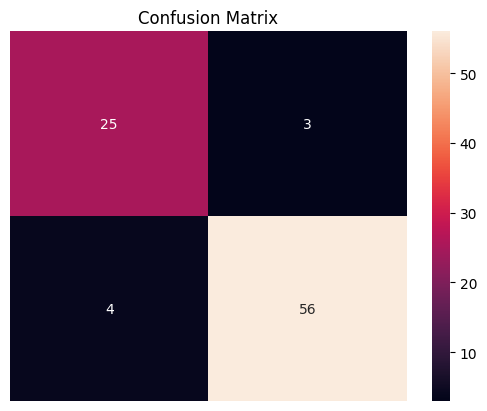

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = []

for train_idx, valid_idx in skf.split(X, y):

    ...

    y_prob = bst.predict(
        X_test,
        num_iteration=bst.best_iteration
    )

    y_pred = (y_prob >= 0.5).astype(int)

    accuracy_scores.append(
        accuracy_score(y_test, y_pred)
    )

    precision_scores.append(
        precision_score(y_test, y_pred)
    )

    recall_scores.append(
        recall_score(y_test, y_pred)
    )

    f1_scores.append(
        f1_score(y_test, y_pred)
    )

    auc_scores.append(
        roc_auc_score(y_test, y_prob)
    )

In [ ]:
print("Accuracy :", np.mean(accuracy_scores))
print("Precision:", np.mean(precision_scores))
print("Recall   :", np.mean(recall_scores))
print("F1 Score :", np.mean(f1_scores))
print("ROC AUC  :", np.mean(auc_scores))

Accuracy : 0.9204545454545453
Precision: 0.9491525423728813
Recall   : 0.9333333333333333
F1 Score : 0.9411764705882353
ROC AUC  : 0.932738095238095


In [ ]:
for i, (acc, pre, rec, f1) in enumerate(
    zip(accuracy_scores, precision_scores, recall_scores, f1_scores),
    start=1
):
    print(
        f"Fold {i}: "
        f"Acc={acc:.4f} | "
        f"Prec={pre:.4f} | "
        f"Recall={rec:.4f} | "
        f"F1={f1:.4f}"
    )

print(f"\nMean Accuracy : {np.mean(accuracy_scores):.4f}")
print(f"Mean Precision: {np.mean(precision_scores):.4f}")
print(f"Mean Recall   : {np.mean(recall_scores):.4f}")
print(f"Mean F1       : {np.mean(f1_scores):.4f}")

Fold 1: Acc=0.9205 | Prec=0.9492 | Recall=0.9333 | F1=0.9412
Fold 2: Acc=0.9205 | Prec=0.9492 | Recall=0.9333 | F1=0.9412
Fold 3: Acc=0.9205 | Prec=0.9492 | Recall=0.9333 | F1=0.9412
Fold 4: Acc=0.9205 | Prec=0.9492 | Recall=0.9333 | F1=0.9412
Fold 5: Acc=0.9205 | Prec=0.9492 | Recall=0.9333 | F1=0.9412

Mean Accuracy : 0.9205
Mean Precision: 0.9492
Mean Recall   : 0.9333
Mean F1       : 0.9412
